Counting Unique Classes

In [3]:
import xml.etree.ElementTree as ET
import pandas as pd
import os

def parse_video_annotations(xml_file):
    tree = ET.parse(xml_file)
    root = tree.getroot()
    records = []
    for track in root.findall(".//track"):
        label = track.attrib["label"]
        records.append({"label": label})
    return pd.DataFrame(records)

# --- Find and count the unique classes ---
xml_filename = '/LizaMutant38annotations.xml'
xml_path = os.path.join('/content/', xml_filename)
df_annotations_summary = parse_video_annotations(xml_path)

print("Class types and counts found in your XML file:")
print(df_annotations_summary['label'].value_counts())

Class types and counts found in your XML file:
label
planktonic               1097
clump dispersed cell      108
single dispersed cell      50
hyphae                     47
psuedohyphae               31
biofilm                    10
Name: count, dtype: int64


Extracting Metadata

In [4]:
def print_element_info(element, indent=0):
    indent_str = '  ' * indent
    text = element.text.strip() if element.text and element.text.strip() else ""

    print(f"{indent_str}- {element.tag}: {text}")

    # Recursively call this function for all child elements
    for child in element:
        print_element_info(child, indent + 1)
try:
    tree = ET.parse(xml_path)
    root = tree.getroot()

    # Find the <meta> tag in the XML file
    meta_tag = root.find('meta')

    if meta_tag is not None:
        print(f"Metadata for '{xml_filename}':")

        for child in meta_tag:
             print_element_info(child)
    else:
        print("No <meta> tag found in this XML file.")

except FileNotFoundError:
    print(f"ERROR: File not found. Please check that '{xml_filename}' is the correct name.")
except Exception as e:
    print(f"An error occurred: {e}")

Metadata for '/LizaMutant38annotations.xml':
- job: 
  - id: 2757699
  - size: 41
  - mode: interpolation
  - overlap: 5
  - bugtracker: 
  - created: 2025-07-26 18:18:29.902087+00:00
  - updated: 2025-08-06 09:50:56.657475+00:00
  - subset: default
  - start_frame: 0
  - stop_frame: 40
  - frame_filter: 
  - segments: 
    - segment: 
      - id: 2759587
      - start: 0
      - stop: 40
      - url: https://app.cvat.ai/api/jobs/2757699
  - owner: 
    - username: cvats
    - email: cytrynbaum@wisc.edu
  - assignee: 
  - labels: 
    - label: 
      - name: single dispersed cell
      - color: #2e25d2
      - type: ellipse
      - attributes: 
    - label: 
      - name: clump dispersed cell
      - color: #265c07
      - type: ellipse
      - attributes: 
    - label: 
      - name: planktonic
      - color: #fb6b60
      - type: ellipse
      - attributes: 
    - label: 
      - name: psuedohyphae
      - color: #0d27ee
      - type: ellipse
      - attributes: 
    - label: 
      

--- Biofilm Stats per Frame (Area & Count) ---
           avg_area  count
frame                     
22     26487.583333      6
23     26487.583333      6
40     44227.000000      4
---------------------------------------------
--- Hyphae Stats per Frame (Length & Count) ---
       avg_length  count
frame                   
3        7.293306      7
4       10.108995     18
5       13.754912     24
6       15.323779     13
19     102.204445      7
20     102.204445      7
22     102.623766      3
23     102.623766      3
40     193.741527      6
---------------------------------------------


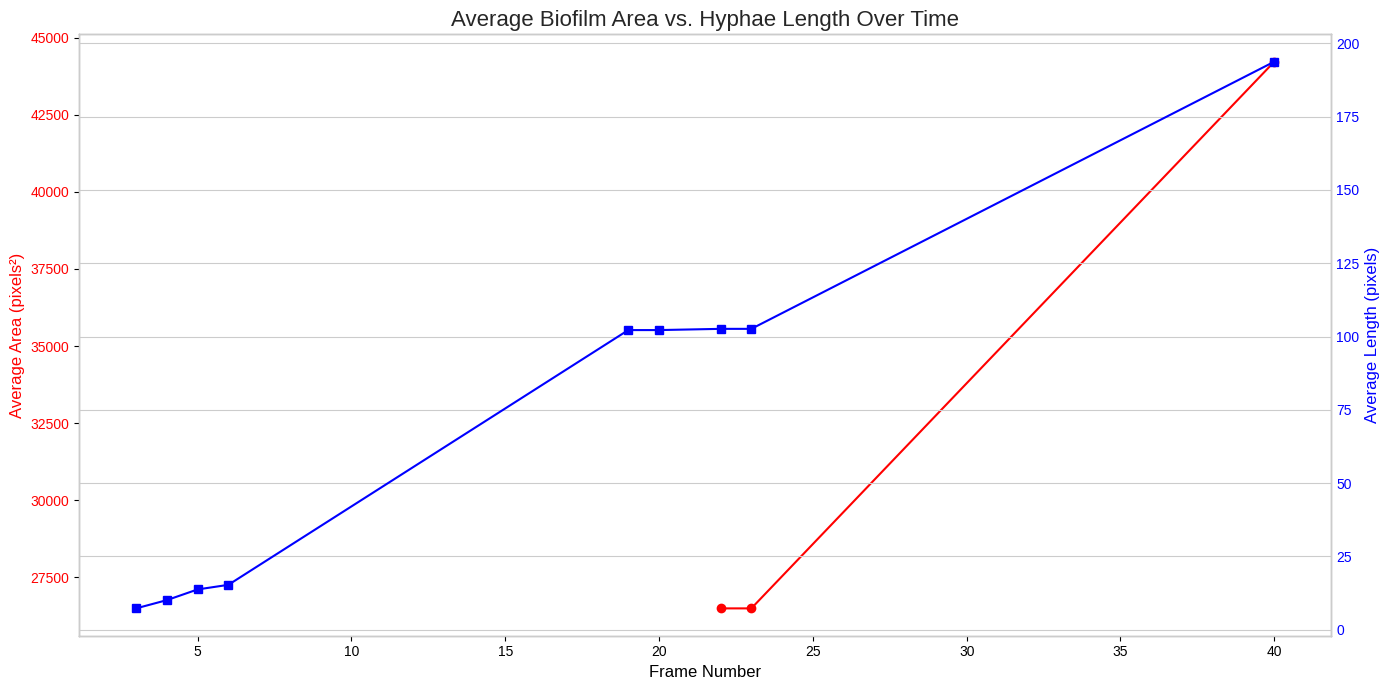

In [5]:
import tifffile as tiff
import cv2
import matplotlib.pyplot as plt
import numpy as np

def parse_all_shapes(xml_file):
    tree = ET.parse(xml_file); root = tree.getroot(); records = []
    for track in root.findall(".//track"):
        track_id = track.attrib["id"]; label = track.attrib["label"]
        for shape in track:
            frame = int(shape.attrib["frame"])
            record = {"frame": frame, "track_id": int(track_id), "label": label, "shape_type": shape.tag}
            if shape.tag == 'ellipse':
                cx, cy, rx, ry = float(shape.attrib['cx']), float(shape.attrib['cy']), float(shape.attrib['rx']), float(shape.attrib['ry'])
                record.update({"xmin": cx - rx, "ymin": cy - ry, "xmax": cx + rx, "ymax": cy + ry})
            elif shape.tag in ['polygon', 'polyline']:
                points_str = shape.attrib['points']; record['points'] = [list(map(float, p.split(','))) for p in points_str.split(';')]
            records.append(record)
    return pd.DataFrame(records)

df_annotations = parse_all_shapes(xml_path)


# CALCULATE BIOFILM AREA
# 1. Find all the individual shapes of biofilm
df_biofilms = df_annotations[df_annotations['label'] == 'biofilm'].copy()

def calculate_polygon_area(points):
    """Calculates the area of a polygon using OpenCV."""
    contour = np.array(points, dtype=np.int32)
    return cv2.contourArea(contour)

# Apply the function to each biofilm annotation
if not df_biofilms.empty:
    # 2. Calculate the area for each one of those biofilm polygons separately
    df_biofilms['area'] = df_biofilms['points'].apply(calculate_polygon_area)

    # 3. Calculate both the average area and the count of biofilms per frame
    biofilm_stats = df_biofilms.groupby('frame')['area'].agg(['mean', 'size'])
    biofilm_stats.rename(columns={'mean': 'avg_area', 'size': 'count'}, inplace=True)

    print("--- Biofilm Stats per Frame (Area & Count) ---")
    print(biofilm_stats)
    print("-" * 45)

    avg_biofilm_area_per_frame = biofilm_stats['avg_area']


# CALCULATE HYPHAE LENGTH
# Filter for hyphae polylines only
df_hyphae = df_annotations[df_annotations['label'] == 'hyphae'].copy()

def calculate_polyline_length(points):
    """Calculates the total length of a polyline by summing segment lengths."""
    length = 0.0
    for i in range(len(points) - 1):
        p1 = np.array(points[i])
        p2 = np.array(points[i+1])
        length += np.linalg.norm(p1 - p2)
    return length

# Apply the function to each hyphae annotation
if not df_hyphae.empty:
    df_hyphae['length'] = df_hyphae['points'].apply(calculate_polyline_length)

    # Calculate both the average length and the count of hyphae per frame
    hyphae_stats = df_hyphae.groupby('frame')['length'].agg(['mean', 'size'])
    hyphae_stats.rename(columns={'mean': 'avg_length', 'size': 'count'}, inplace=True)

    print("--- Hyphae Stats per Frame (Length & Count) ---")
    print(hyphae_stats)
    print("-" * 45)

    avg_hyphae_length_per_frame = hyphae_stats['avg_length']


# VISUALIZE THE RESULTS
fig, ax1 = plt.subplots(figsize=(14, 7))
plt.style.use('seaborn-v0_8-whitegrid')

# Plot Biofilm Area on the first y-axis
if 'avg_biofilm_area_per_frame' in locals():
    ax1.plot(avg_biofilm_area_per_frame.index, avg_biofilm_area_per_frame.values, color='red', marker='o', label='Avg. Biofilm Area')
    ax1.set_xlabel('Frame Number', fontsize=12)
    ax1.set_ylabel('Average Area (pixels²)', color='red', fontsize=12)
    ax1.tick_params(axis='y', labelcolor='red')

# Create a second y-axis that shares the same x-axis
ax2 = ax1.twinx()

# Plot Hyphae Length on the second y-axis
if 'avg_hyphae_length_per_frame' in locals():
    ax2.plot(avg_hyphae_length_per_frame.index, avg_hyphae_length_per_frame.values, color='blue', marker='s', label='Avg. Hyphae Length')
    ax2.set_ylabel('Average Length (pixels)', color='blue', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='blue')

plt.title('Average Biofilm Area vs. Hyphae Length Over Time', fontsize=16)
fig.tight_layout()
plt.show()

In [ ]:
FRAME_TO_ANALYZE = 40

def parse_all_shapes(xml_file):
    tree = ET.parse(xml_file); root = tree.getroot(); records = []
    for track in root.findall(".//track"):
        track_id = track.attrib["id"]; label = track.attrib["label"]
        for shape in track:
            frame = int(shape.attrib["frame"])
            record = {"frame": frame, "track_id": int(track_id), "label": label, "shape_type": shape.tag}
            if shape.tag == 'ellipse':
                cx, cy, rx, ry = float(shape.attrib['cx']), float(shape.attrib['cy']), float(shape.attrib['rx']), float(shape.attrib['ry'])
                record.update({"xmin": cx - rx, "ymin": cy - ry, "xmax": cx + rx, "ymax": cy + ry})
            elif shape.tag in ['polygon', 'polyline']:
                points_str = shape.attrib['points']; record['points'] = [list(map(float, p.split(','))) for p in points_str.split(';')]
            records.append(record)
    return pd.DataFrame(records)

try:
    xml_path = os.path.join('/content/', xml_filename)
    df_annotations = parse_all_shapes(xml_path)

    print(f"--- Analysis for Frame {FRAME_TO_ANALYZE} ---")

    # --- Biofilm Calculations ---
    df_biofilms = df_annotations[df_annotations['label'] == 'biofilm'].copy()
    if not df_biofilms.empty:
        df_biofilms['area'] = df_biofilms['points'].apply(lambda p: cv2.contourArea(np.array(p, dtype=np.int32)))
        biofilms_in_frame = df_biofilms[df_biofilms['frame'] == FRAME_TO_ANALYZE]

        if not biofilms_in_frame.empty:
            print(f"\nBiofilms Found: {len(biofilms_in_frame)}")
            print(f"  - Total Area: {biofilms_in_frame['area'].sum():.2f} pixels²")
            print(f"  - Average Area: {biofilms_in_frame['area'].mean():.2f} pixels²")
        else:
            print("\nNo biofilms found in this frame.")

    # --- Hyphae Calculations ---
    df_hyphae = df_annotations[df_annotations['label'] == 'hyphae'].copy()
    def calculate_polyline_length(points):
        return sum(np.linalg.norm(np.array(points[i]) - np.array(points[i+1])) for i in range(len(points) - 1))

    if not df_hyphae.empty:
        df_hyphae['length'] = df_hyphae['points'].apply(calculate_polyline_length)
        hyphae_in_frame = df_hyphae[df_hyphae['frame'] == FRAME_TO_ANALYZE]

        if not hyphae_in_frame.empty:
            print(f"\nHyphae Found: {len(hyphae_in_frame)}")
            print(f"  - Total Length: {hyphae_in_frame['length'].sum():.2f} pixels")
            print(f"  - Average Length: {hyphae_in_frame['length'].mean():.2f} pixels")
        else:
            print("\nNo hyphae found in this frame.")

except Exception as e:
    print(f"An error occurred: {e}")

--- Analysis for Frame 40 ---

Biofilms Found: 4
  - Total Area: 176908.00 pixels²
  - Average Area: 44227.00 pixels²

Hyphae Found: 6
  - Total Length: 1162.45 pixels
  - Average Length: 193.74 pixels


--- Analysis for Frame 0 ---
Total annotations found: 192

Breakdown by cell type:
label
planktonic    192
Name: count, dtype: int64
-------------------------


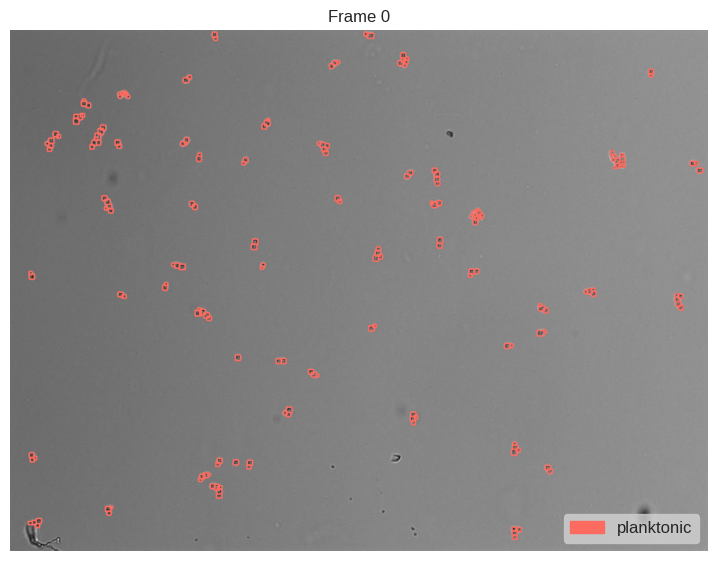

--- Analysis for Frame 1 ---
Total annotations found: 399

Breakdown by cell type:
label
planktonic    399
Name: count, dtype: int64
-------------------------


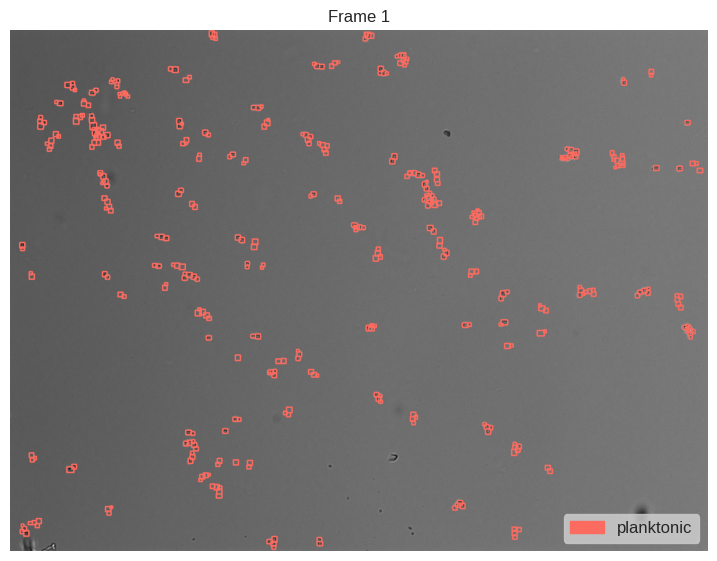

--- Analysis for Frame 2 ---
Total annotations found: 411

Breakdown by cell type:
label
planktonic    411
Name: count, dtype: int64
-------------------------


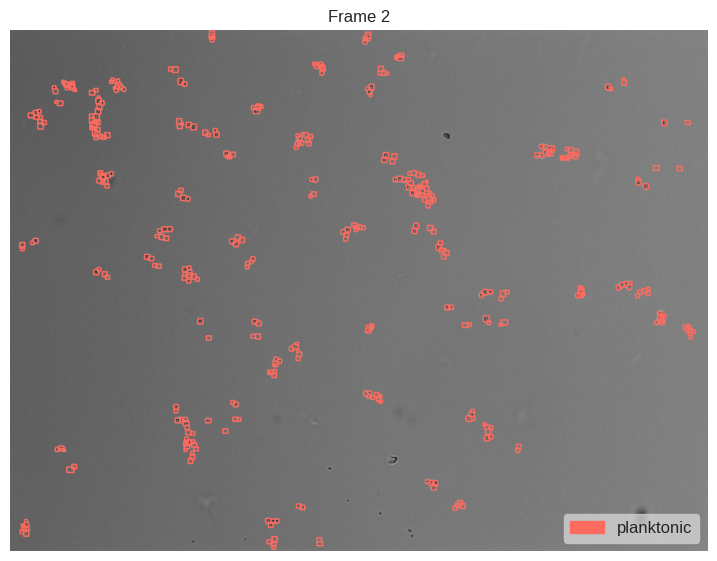

--- Analysis for Frame 3 ---
Total annotations found: 427

Breakdown by cell type:
label
planktonic    420
hyphae          7
Name: count, dtype: int64
-------------------------


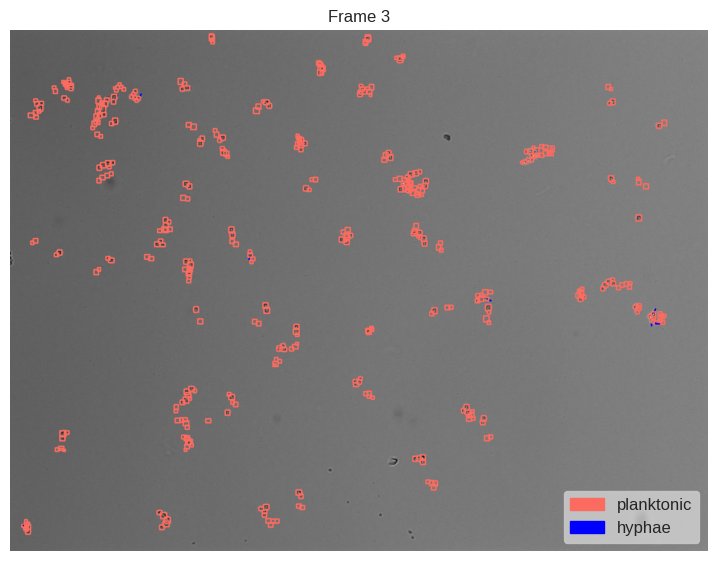

--- Analysis for Frame 4 ---
Total annotations found: 474

Breakdown by cell type:
label
planktonic      455
hyphae           18
psuedohyphae      1
Name: count, dtype: int64
-------------------------


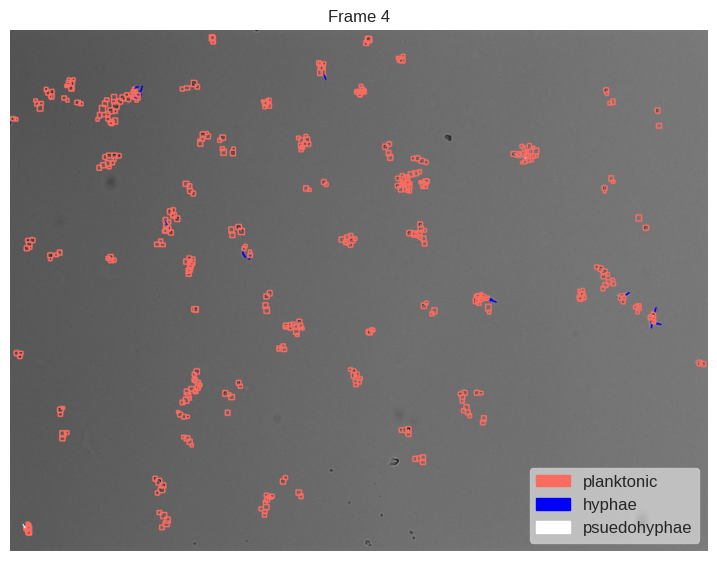

--- Analysis for Frame 5 ---
Total annotations found: 295

Breakdown by cell type:
label
planktonic      270
hyphae           24
psuedohyphae      1
Name: count, dtype: int64
-------------------------


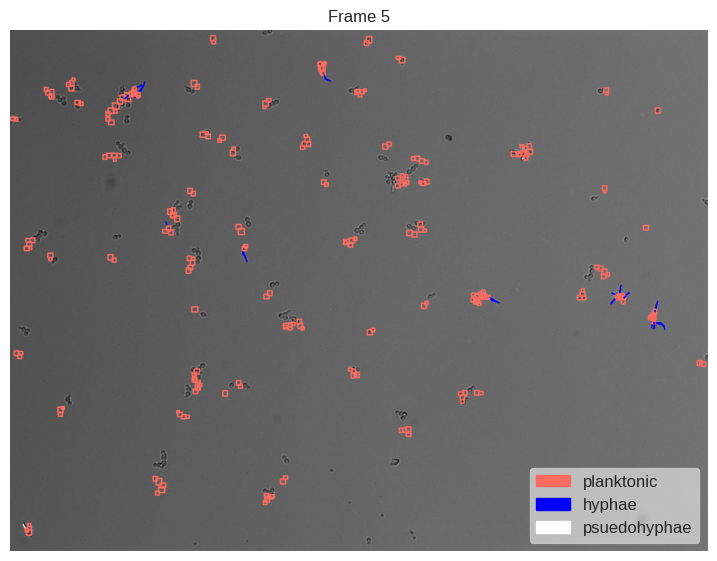

--- Analysis for Frame 6 ---
Total annotations found: 44

Breakdown by cell type:
label
planktonic    31
hyphae        13
Name: count, dtype: int64
-------------------------


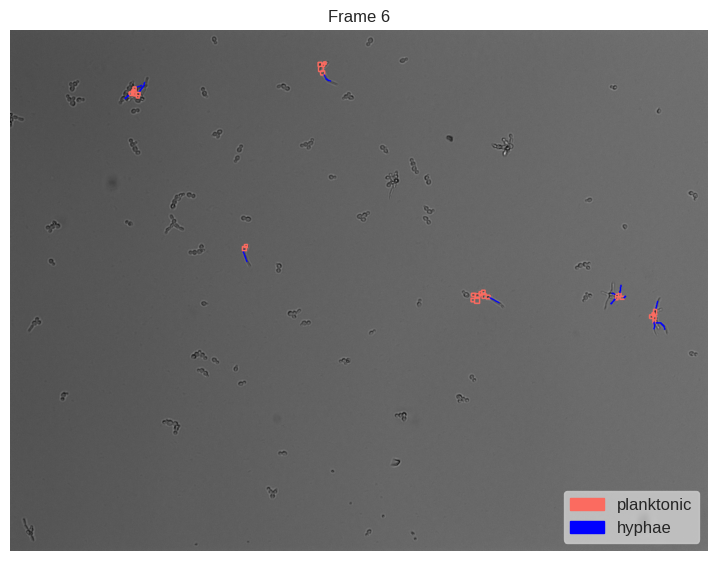

--- Analysis for Frame 18 ---
Total annotations found: 7

Breakdown by cell type:
label
clump dispersed cell    7
Name: count, dtype: int64
-------------------------


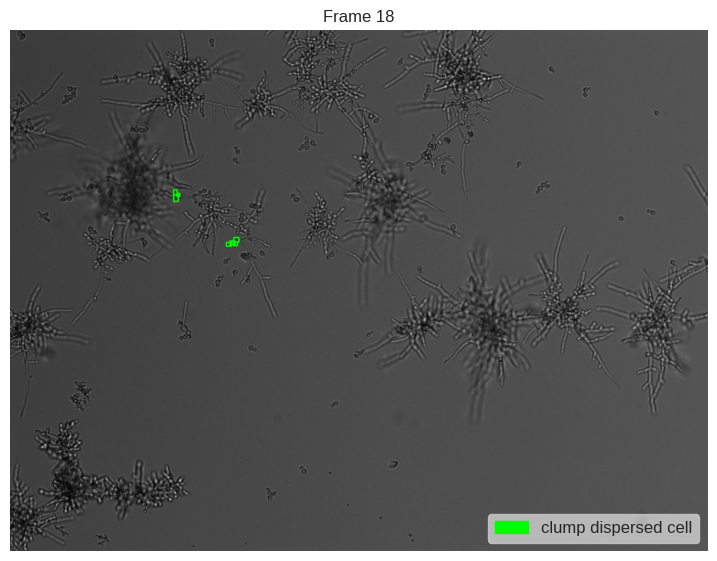

--- Analysis for Frame 19 ---
Total annotations found: 74

Breakdown by cell type:
label
clump dispersed cell     46
psuedohyphae             19
hyphae                    7
single dispersed cell     2
Name: count, dtype: int64
-------------------------


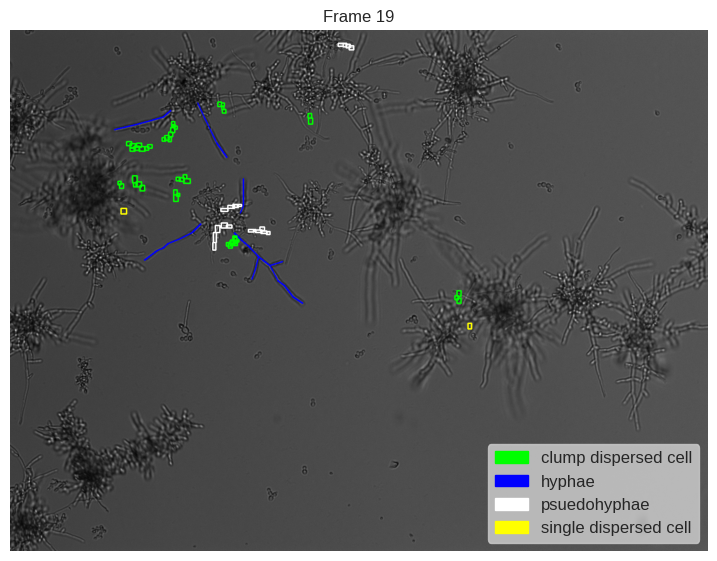

--- Analysis for Frame 20 ---
Total annotations found: 67

Breakdown by cell type:
label
clump dispersed cell     39
psuedohyphae             19
hyphae                    7
single dispersed cell     2
Name: count, dtype: int64
-------------------------


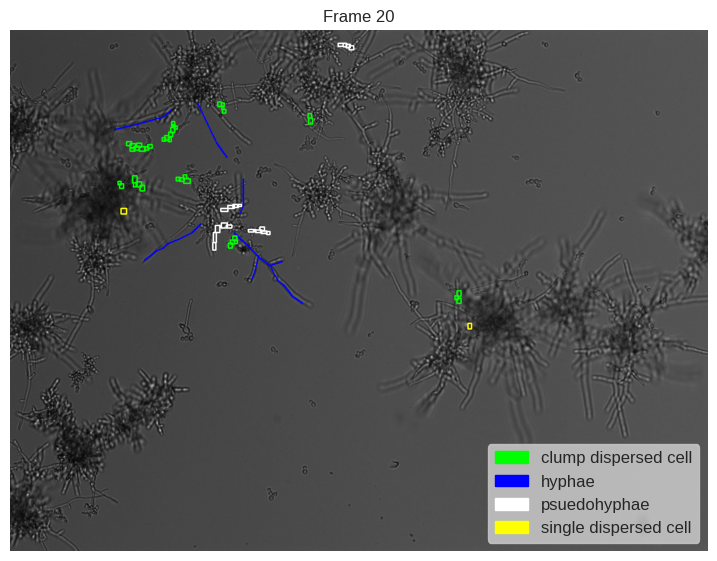

--- Analysis for Frame 22 ---
Total annotations found: 49

Breakdown by cell type:
label
clump dispersed cell     15
psuedohyphae             11
planktonic                8
biofilm                   6
single dispersed cell     6
hyphae                    3
Name: count, dtype: int64
-------------------------


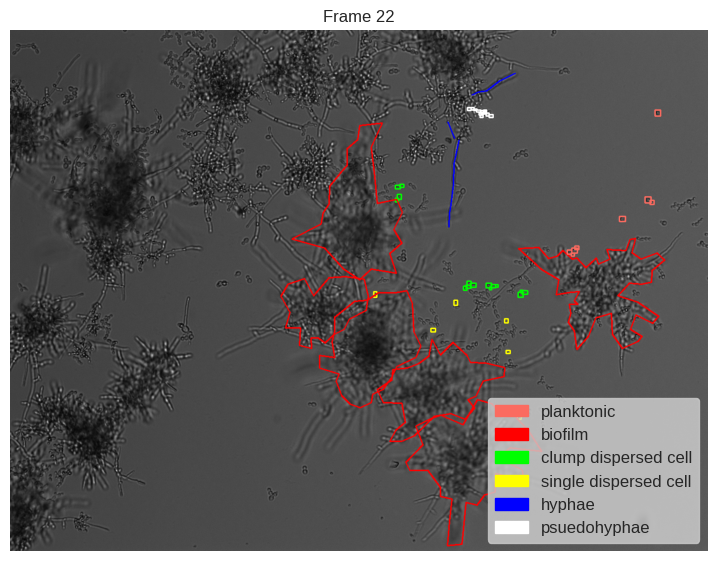

--- Analysis for Frame 23 ---
Total annotations found: 49

Breakdown by cell type:
label
clump dispersed cell     15
psuedohyphae             11
planktonic                8
biofilm                   6
single dispersed cell     6
hyphae                    3
Name: count, dtype: int64
-------------------------


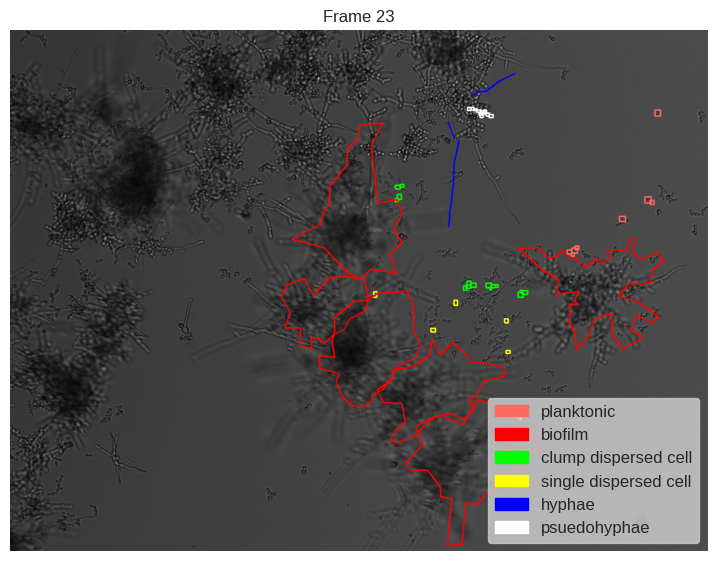

--- Analysis for Frame 40 ---
Total annotations found: 99

Breakdown by cell type:
label
clump dispersed cell     47
single dispersed cell    42
hyphae                    6
biofilm                   4
Name: count, dtype: int64
-------------------------


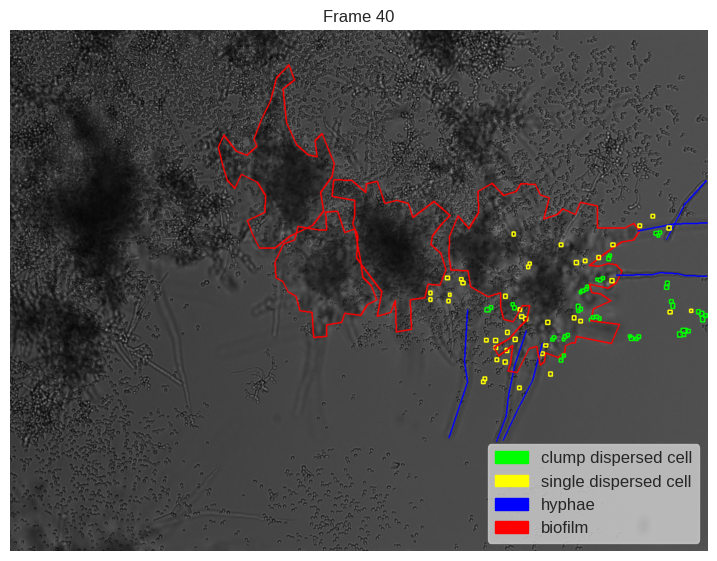

In [15]:
# color_map = {
#     'single dispersed cell': (210, 37, 46),      # Original color: #2e25d2
#     'clump dispersed cell':  (7, 92, 38),        # Original color: #265c07
#     'planktonic':            (96, 107, 251),     # Original color: #fb6b60
#     'psuedohyphae':          (238, 39, 13),      # Original color: #0d27ee
#     'hyphae':                (1, 138, 171),      # Original color: #ab8a01
#     'biofilm':               (26, 29, 75),       # Original color: #4b1d1a
#     'yeast form':            (95, 80, 114),      # Original color: #72505f
# }

# # This default color will be used if any other unexpected labels appear
# default_color = (255, 255, 255) # White

# --- Define File Paths ---
tif_filename = '/LizaMutant38.tif'
xml_filename = '/LizaMutant38annotations.xml'

color_map = {
    'hyphae': (255, 0, 0),                   # Blue
    'single dispersed cell': (0, 255, 255),   # Yellow
    'pseudohyphae': (255, 0, 255),            # Magenta
    'clump dispersed cell': (0, 255, 0),      # Green
    'planktonic': (96, 107, 251),
    'biofilm': (0, 0, 255),
    'yeast form': (95, 80, 114)
}
default_color = (255, 255, 255) # White

def parse_all_shapes(xml_file):
    tree = ET.parse(xml_file); root = tree.getroot(); records = []
    for track in root.findall(".//track"):
        track_id = track.attrib["id"]; label = track.attrib["label"]
        for shape in track:
            frame = int(shape.attrib["frame"]); record = {"frame": frame, "track_id": int(track_id), "label": label, "shape_type": shape.tag}
            if shape.tag == 'ellipse':
                cx, cy, rx, ry = float(shape.attrib['cx']), float(shape.attrib['cy']), float(shape.attrib['rx']), float(shape.attrib['ry'])
                record.update({"xmin": cx - rx, "ymin": cy - ry, "xmax": cx + rx, "ymax": cy + ry})
            elif shape.tag in ['polygon', 'polyline']:
                points_str = shape.attrib['points']; record['points'] = [list(map(float, p.split(','))) for p in points_str.split(';')]
            records.append(record)
    return pd.DataFrame(records)

try:
    tif_path = os.path.join('/content/', tif_filename)
    xml_path = os.path.join('/content/', xml_filename)

    df_annotations = parse_all_shapes(xml_path)
    video = tiff.imread(tif_path)

    # --- MAIN LOOP TO PROCESS ONLY FRAMES WITH ANNOTATIONS ---
    annotated_frames = sorted(df_annotations['frame'].unique())

    for frame_number in annotated_frames:
        single_frame = video[frame_number]
        annotations_for_frame = df_annotations[df_annotations['frame'] == frame_number]

        if not annotations_for_frame.empty:
            total_count = len(annotations_for_frame)
            counts_by_type = annotations_for_frame['label'].value_counts()

            print(f"--- Analysis for Frame {frame_number} ---")
            print(f"Total annotations found: {total_count}")
            print("\nBreakdown by cell type:")
            print(counts_by_type)
            print("-" * 25)

            # --- VISUALIZATION for the current frame ---
            gray_8bit = cv2.normalize(single_frame, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
            image_bgr = cv2.cvtColor(gray_8bit, cv2.COLOR_GRAY2BGR)

            for index, row in annotations_for_frame.iterrows():
                label = row['label']; color = color_map.get(label, default_color)
                if row['shape_type'] == 'ellipse':
                    xmin, ymin, xmax, ymax = int(row['xmin']), int(row['ymin']), int(row['xmax']), int(row['ymax'])
                    cv2.rectangle(image_bgr, (xmin, ymin), (xmax, ymax), color, 2)
                elif row['shape_type'] in ['polygon', 'polyline']:
                    points = np.array(row['points'], dtype=np.int32).reshape((-1, 1, 2)); is_closed = (row['shape_type'] == 'polygon')
                    cv2.polylines(image_bgr, [points], is_closed, color, 2)

            image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

            fig, ax = plt.subplots(figsize=(9, 9))
            ax.imshow(image_rgb); ax.set_title(f"Frame {frame_number}"); ax.axis('off')

            labels_in_frame = annotations_for_frame['label'].unique()
            legend_patches = []
            for label in labels_in_frame:
                bgr_color = color_map.get(label, default_color); rgb_color = (bgr_color[2]/255, bgr_color[1]/255, bgr_color[0]/255)
                patch = mpatches.Patch(color=rgb_color, label=label)
                legend_patches.append(patch)
            ax.legend(handles=legend_patches, loc='lower right', fontsize='large', frameon=True, facecolor='lightgray')

            plt.show()

except FileNotFoundError:
    print(f"ERROR: A file was not found. Check that '{tif_filename}' and '{xml_filename}' exist in the '/content/' directory.")
except Exception as e:
    print(f"An error occurred: {e}")